In [1]:
# =============================================================================
# TCC — Caracterização Não Supervisionada de Perturbações Elétricas
# Rafael Benzaquem Neto | UFRR — ECAI 4.0
#
# MÓDULO FINAL — Curadoria Semântica (Handoff)
#
# Entradas (saídas dos módulos anteriores):
#   • Módulo 1 → arquivo(s) .mat  (oscilografias brutas + metadados matAux)
#   • Módulo 2 → Z_latente.npy   shape (N, LATENT_DIM)
#   • Módulo 3 → labels_kmeans.npy shape (N,)
#                resultados_completos.csv
#                anomalias.csv
#                centroides_clusters.csv
#
# O módulo cruza os índices de cada cluster com os metadados do Módulo 1,
# calcula a V_rms mínima por cluster e rotula fisicamente cada grupo
# conforme a IEEE Std 1159:2019. Gera um relatório técnico completo.
# =============================================================================
# Compatível com Google Colab. Execute célula a célula (▶).
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação de dependências
# ─────────────────────────────────────────────────────────────────────────────
#!pip install scipy scikit-learn matplotlib numpy pandas --quiet

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import warnings
import textwrap
from collections import Counter
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

#from google.colab import drive

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 3 — Configurações globais
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
from datetime import datetime

MAT_SOURCE = './0_dados_brutos'

V_NOMINAL_PEAK_KV = 95.5
FREQ_NOMINAL_HZ   = 60.0
SAMPLES_PER_CYCLE = 64
NUM_CYCLES        = 6
WINDOW_SIZE       = SAMPLES_PER_CYCLE * NUM_CYCLES  # 384

AUX_COL_NAMES = [
    'tipo_evento', 'amp_max_pos', 'amp_max_neg', 'V_rms_max_aux',
    'V_rms_min_aux', 'ts_inicio', 'ts_fim', 'duracao_ciclos',
    'duracao_ms', 'freq_medida_hz', 'n_amostras', 'n_ciclos_pre',
    'n_ciclos_pos', 'flag_A', 'flag_B', 'flag_C', 'flag_N',
    'flag_extra', 'ts_pico', 'codigo_evento',
]

IEEE_1159 = [
    ('Interrupção',    'Interrupção de Tensão',             0.00, 0.10, '#6d6875'),
    ('Sag Severo',     'Afundamento Severo de Tensão',      0.10, 0.50, '#e63946'),
    ('Sag Moderado',   'Afundamento Moderado de Tensão',    0.50, 0.70, '#f4a261'),
    ('Sag Leve',       'Afundamento Leve de Tensão',        0.70, 0.90, '#e9c46a'),
    ('Tensão Normal',  'Operação em Tensão Normal',         0.90, 1.10, '#2a9d8f'),
    ('Swell Leve',     'Elevação Leve de Tensão',           1.10, 1.40, '#457b9d'),
    ('Swell Moderado', 'Elevação Moderada de Tensão',       1.40, 1.80, '#1d3557'),
    ('Swell Severo',   'Elevação Severa de Tensão',         1.80, 9.99, '#264653'),
]

CORES_CLUSTER  = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a',
                  '#f4a261', '#6d6875', '#80b918', '#264653']
SUFFIX_OPTIONS = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

# ─── Seleção dinâmica: saída do Módulo 2 (CAE) ───────────────────────────────
BASE_CAE   = Path('./2_dados_cae')
BASE_CLUST = Path('./3_dados_clustering')

subdirs_cae   = sorted([d for d in BASE_CAE.iterdir()   if d.is_dir()])
subdirs_clust = sorted([d for d in BASE_CLUST.iterdir() if d.is_dir()])

if not subdirs_cae:
    raise FileNotFoundError(f"Nenhum subdiretório encontrado em '{BASE_CAE}'")
if not subdirs_clust:
    raise FileNotFoundError(f"Nenhum subdiretório encontrado em '{BASE_CLUST}'")

print("Pastas de execução do CAE disponíveis:")
for i, d in enumerate(subdirs_cae):
    print(f"  [{i}] {d.name}")

print("\nPastas de clusterização disponíveis:")
for i, d in enumerate(subdirs_clust):
    print(f"  [{i}] {d.name}")

# Valores iniciais
LATENT_NPY    = str(subdirs_cae[0]   / "Z_latente.npy")
_clust_dir    = subdirs_clust[0]
LABELS_NPY    = str(_clust_dir / "labels_kmeans.npy")
RESULT_CSV    = str(_clust_dir / "resultados_completos.csv")
ANOMALIAS_CSV = str(_clust_dir / "anomalias.csv")
CENTROIDES_CSV= str(_clust_dir / "centroides_clusters.csv")

try:
    import ipywidgets as widgets
    from IPython.display import display

    _opcoes_cae   = {d.name: d for d in subdirs_cae}
    _opcoes_clust = {d.name: d for d in subdirs_clust}

    sel_cae = widgets.Dropdown(
        options=list(_opcoes_cae.keys()),
        description="Execução CAE:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="55%"),
    )
    sel_clust = widgets.Dropdown(
        options=list(_opcoes_clust.keys()),
        description="Clusterização:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="55%"),
    )
    _out = widgets.Output()

    def _update_cae(change):
        global LATENT_NPY
        LATENT_NPY = str(_opcoes_cae[change["new"]] / "Z_latente.npy")
        with _out:
            _out.clear_output(wait=True)
            print(f"📂 CAE        : {LATENT_NPY}")
            print(f"📂 Clustering : {_clust_dir}")

    def _update_clust(change):
        global _clust_dir, LABELS_NPY, RESULT_CSV, ANOMALIAS_CSV, CENTROIDES_CSV
        _clust_dir     = _opcoes_clust[change["new"]]
        LABELS_NPY     = str(_clust_dir / "labels_kmeans.npy")
        RESULT_CSV     = str(_clust_dir / "resultados_completos.csv")
        ANOMALIAS_CSV  = str(_clust_dir / "anomalias.csv")
        CENTROIDES_CSV = str(_clust_dir / "centroides_clusters.csv")
        with _out:
            _out.clear_output(wait=True)
            print(f"📂 CAE        : {LATENT_NPY}")
            print(f"📂 Clustering : {_clust_dir}")

    sel_cae.observe(_update_cae,   names="value")
    sel_clust.observe(_update_clust, names="value")
    display(widgets.VBox([sel_cae, sel_clust, _out]))

except ImportError:
    _i_cae   = int(input(f"CAE — Digite o número [0-{len(subdirs_cae)-1}]: "))
    _i_clust = int(input(f"Clust — Digite o número [0-{len(subdirs_clust)-1}]: "))
    LATENT_NPY     = str(subdirs_cae[_i_cae]     / "Z_latente.npy")
    _clust_dir     = subdirs_clust[_i_clust]
    LABELS_NPY     = str(_clust_dir / "labels_kmeans.npy")
    RESULT_CSV     = str(_clust_dir / "resultados_completos.csv")
    ANOMALIAS_CSV  = str(_clust_dir / "anomalias.csv")
    CENTROIDES_CSV = str(_clust_dir / "centroides_clusters.csv")

print(f"\n📂 CAE        : {LATENT_NPY}")
print(f"📂 Clustering : {_clust_dir}")

# ─── Criação dinâmica do diretório de saída ──────────────────────────────────
_timestamp  = datetime.now().strftime("%Y%m%d_%H%M")
_output_dir = Path("./4_dados_curadoria") / f"exec_{_timestamp}"
_output_dir.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = str(_output_dir)

print("\n✅ Configurações carregadas.")
print(f"   Fonte .mat : {MAT_SOURCE}")
print(f"   Saída      : {OUTPUT_DIR}")

Pastas de execução do CAE disponíveis:
  [0] exec_20260412_1800_16_32_128_100
  [1] old
  [2] old_v2

Pastas de clusterização disponíveis:
  [0] exec_20260412_1851_2_8_50
  [1] exec_20260412_1900_2_8_50
  [2] exec_20260412_1904_2_8_50
  [3] old
  [4] old_v2



📂 CAE        : 2_dados_cae/exec_20260412_1800_16_32_128_100/Z_latente.npy
📂 Clustering : 3_dados_clustering/exec_20260412_1851_2_8_50

✅ Configurações carregadas.
   Fonte .mat : ./0_dados_brutos
   Saída      : 4_dados_curadoria/exec_20260412_1910


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 4 — Carregamento de todas as saídas dos módulos anteriores
# ─────────────────────────────────────────────────────────────────────────────

def carregar_entradas(mat_source, latent_npy, labels_npy,
                      result_csv, anomalias_csv, centroides_csv):
    """
    Carrega e valida todas as saídas dos módulos 1, 2 e 3.
    Retorna um dicionário com todos os objetos necessários.
    """
    dados = {}

    # ── Módulo 2: vetores latentes ────────────────────────────────────────────
    print("\n📦 Carregando saídas dos módulos anteriores...")
    assert os.path.exists(latent_npy), f"Não encontrado: {latent_npy}"
    dados['Z'] = np.load(latent_npy).astype(np.float32)
    print(f"   Z_latente.npy       : {dados['Z'].shape}")

    # ── Módulo 3: labels e CSVs ───────────────────────────────────────────────
    assert os.path.exists(labels_npy), f"Não encontrado: {labels_npy}"
    dados['labels'] = np.load(labels_npy).astype(int)
    print(f"   labels_kmeans.npy   : {dados['labels'].shape}  "
          f"k={len(np.unique(dados['labels']))}")

    assert os.path.exists(result_csv), f"Não encontrado: {result_csv}"
    dados['df_result'] = pd.read_csv(result_csv)
    print(f"   resultados_completos: {dados['df_result'].shape}")

    assert os.path.exists(anomalias_csv), f"Não encontrado: {anomalias_csv}"
    dados['df_anomalias'] = pd.read_csv(anomalias_csv)

    assert os.path.exists(centroides_csv), f"Não encontrado: {centroides_csv}"
    dados['df_centroides'] = pd.read_csv(centroides_csv, index_col=0)

    # ── Módulo 1: metadados do .mat ──────────────────────────────────────────
    # Suporte a arquivo único ou diretório
    if os.path.isdir(mat_source):
        import glob
        arquivos = sorted(glob.glob(os.path.join(MAT_SOURCE, '**', '*.mat'), recursive=True))
   #    arquivos = sorted(glob.glob(os.path.join(diretorio, '*.mat')))
    else:
        arquivos = [mat_source]

    assert arquivos, f"Nenhum .mat encontrado em: {mat_source}"

    lista_aux, lista_va, lista_vb, lista_vc = [], [], [], []
    for arq in arquivos:
        m = scipy.io.loadmat(arq)
        aux_df = pd.DataFrame(
            m['matAux'][:, :len(AUX_COL_NAMES)],
            columns=AUX_COL_NAMES
        )
        aux_df['arquivo_origem'] = Path(arq).name
        lista_aux.append(aux_df)
        lista_va.append(m['matXVa'])
        lista_vb.append(m['matXVb'])
        lista_vc.append(m['matXVc'])

    dados['df_aux']  = pd.concat(lista_aux, ignore_index=True)
    dados['Va_kv']   = np.vstack(lista_va)
    dados['Vb_kv']   = np.vstack(lista_vb)
    dados['Vc_kv']   = np.vstack(lista_vc)

    print(f"   df_aux (metadados)  : {dados['df_aux'].shape}  "
          f"({len(arquivos)} arquivo(s) .mat)")
    print(f"   Formas de onda      : Va{dados['Va_kv'].shape} "
          f"Vb{dados['Vb_kv'].shape} Vc{dados['Vc_kv'].shape}")

    # ── Consistência ──────────────────────────────────────────────────────────
    N_orig  = len(dados['df_aux'])
    N_label = len(dados['labels'])
    N_z     = len(dados['Z'])

    print(f"\n   Eventos originais (df_aux) : {N_orig}")
    print(f"   Vetores latentes (Z)       : {N_z}")
    print(f"   Labels K-Means             : {N_label}")

    if N_label == N_orig:
        dados['mapeamento'] = 'direto'
        print("   → Mapeamento: 1:1 (janela = evento original)")
    else:
        dados['mapeamento'] = 'bloco'
        janelas_por_evento = N_label // N_orig
        resto = N_label % N_orig
        print(f"   → Mapeamento: bloco (~{janelas_por_evento} janelas/evento, "
              f"resto={resto})")

    dados['N_orig']  = N_orig
    dados['N_label'] = N_label
    dados['K']       = len(np.unique(dados['labels']))
    return dados


dados = carregar_entradas(
    MAT_SOURCE, LATENT_NPY, LABELS_NPY,
    RESULT_CSV, ANOMALIAS_CSV, CENTROIDES_CSV
)


📦 Carregando saídas dos módulos anteriores...
   Z_latente.npy       : (11928, 16)
   labels_kmeans.npy   : (11928,)  k=8
   resultados_completos: (11928, 13)
   df_aux (metadados)  : (12092, 21)  (378 arquivo(s) .mat)
   Formas de onda      : Va(12092, 384) Vb(12092, 384) Vc(12092, 384)

   Eventos originais (df_aux) : 12092
   Vetores latentes (Z)       : 11928
   Labels K-Means             : 11928
   → Mapeamento: bloco (~0 janelas/evento, resto=11928)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 5 — Enriquecimento do df_aux com métricas das formas de onda
#
# MELHORIA M5: V_rms_pre calculado sobre os ciclos ANTES do início da
# perturbação, usando n_ciclos_pre do matAux. Ciclo 0 pode já estar em sag.
# ─────────────────────────────────────────────────────────────────────────────

def calcular_metricas_formas_de_onda(df_aux, Va_kv, Vb_kv, Vc_kv,
                                      v_nom=V_NOMINAL_PEAK_KV,
                                      spc=SAMPLES_PER_CYCLE):
    """
    Calcula por evento:
      V_rms_min_pu  — menor RMS de ciclo entre as 3 fases
      V_rms_max_pu  — maior RMS de ciclo entre as 3 fases
      V_rms_pre_pu  — RMS médio dos ciclos PRÉ-FALTA (coluna n_ciclos_pre)
                      [MELHORIA M5: usa n_ciclos_pre, não apenas o ciclo 0]
      amp_pico_pu   — amplitude de pico absoluta
      fases_afetadas — fases com RMS < 0.90 p.u.
    """
    n_eventos = len(df_aux)
    v_min, v_max, v_pre, pico, fases = [], [], [], [], []

    for i in range(n_eventos):
        rms_por_fase = {}
        for nome, canal in zip(['A', 'B', 'C'],
                               [Va_kv[i], Vb_kv[i], Vc_kv[i]]):
            s  = canal / v_nom
            nc = len(s) // spc
            rms_por_fase[nome] = [
                np.sqrt(np.mean(s[c * spc:(c + 1) * spc] ** 2))
                for c in range(nc)
            ]

        todos = [r for lst in rms_por_fase.values() for r in lst]
        v_min.append(min(todos))
        v_max.append(max(todos))

        # ── M5: V_rms_pre sobre os ciclos pré-falta reais ────────────────────
        n_pre = int(df_aux.iloc[i].get('n_ciclos_pre', 0))
        if n_pre <= 0:
            n_pre = 3   # fallback: 3 primeiros ciclos como estimativa pré-falta

        rms_pre_fases = []
        for lst in rms_por_fase.values():
            # Usa os últimos n_pre ciclos antes do centro da janela
            ciclos_pre = lst[:n_pre] if len(lst) >= n_pre else lst
            rms_pre_fases.extend(ciclos_pre)

        v_pre.append(np.mean(rms_pre_fases) if rms_pre_fases else np.nan)
        # ─────────────────────────────────────────────────────────────────────

        sinal = np.concatenate([
            Va_kv[i] / v_nom, Vb_kv[i] / v_nom, Vc_kv[i] / v_nom
        ])
        pico.append(float(np.max(np.abs(sinal))))

        fases_af = ''.join(
            f for f in ['A', 'B', 'C']
            if min(rms_por_fase[f]) < 0.90
        )
        fases.append(fases_af if fases_af else 'Normal')

    df_aux = df_aux.copy()
    df_aux['V_rms_min_pu']    = v_min
    df_aux['V_rms_max_pu']    = v_max
    df_aux['V_rms_pre_pu']    = v_pre
    df_aux['amp_pico_pu']     = pico
    df_aux['fases_afetadas']  = fases
    df_aux['evento_idx_orig'] = range(n_eventos)
    return df_aux


print("⏳ Calculando métricas das formas de onda (com V_rms_pre corrigido)...")
dados['df_aux'] = calcular_metricas_formas_de_onda(
    dados['df_aux'], dados['Va_kv'], dados['Vb_kv'], dados['Vc_kv']
)

desc = dados['df_aux']['V_rms_min_pu'].describe()
print(f"✅ V_rms_min: mean={desc['mean']:.4f}  std={desc['std']:.4f}  "
      f"[{desc['min']:.4f}, {desc['max']:.4f}]")
pre_med = dados['df_aux']['V_rms_pre_pu'].mean()
print(f"   V_rms_pre (pré-falta): {pre_med:.4f} p.u. "
      f"({'✅ plausível (≈1 p.u.)' if pre_med > 0.85 else '⚠️  verificar n_ciclos_pre'})")

⏳ Calculando métricas das formas de onda (com V_rms_pre corrigido)...
✅ V_rms_min: mean=0.6934  std=0.0841  [0.0000, 0.7142]
   V_rms_pre (pré-falta): 0.6993 p.u. (⚠️  verificar n_ciclos_pre)


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 6 — Mapeamento labels → eventos originais
# ─────────────────────────────────────────────────────────────────────────────

def mapear_labels(labels, N_orig, N_label, mapeamento):
    if mapeamento == 'direto':
        return labels.copy()
    bloco = N_label // N_orig
    cluster_orig = np.zeros(N_orig, dtype=int)
    if bloco >= 1:
        for i in range(N_orig):
            seg = labels[i * bloco: min((i + 1) * bloco, N_label)]
            if len(seg):
                cluster_orig[i] = Counter(seg).most_common(1)[0][0]
    else:
        for j in range(N_label):
            idx = min(int(j * N_orig / N_label), N_orig - 1)
            cluster_orig[idx] = labels[j]
    return cluster_orig


cluster_orig = mapear_labels(
    dados['labels'], dados['N_orig'], dados['N_label'], dados['mapeamento']
)
dados['df_aux']['cluster'] = cluster_orig

print(f"✅ Mapeamento ({dados['mapeamento']}) concluído.")
for c, n in zip(*np.unique(cluster_orig, return_counts=True)):
    print(f"   Cluster {c}: {n} eventos ({n/dados['N_orig']*100:.1f}%)")

✅ Mapeamento (bloco) concluído.
   Cluster 0: 1928 eventos (15.9%)
   Cluster 1: 2428 eventos (20.1%)
   Cluster 2: 1102 eventos (9.1%)
   Cluster 3: 981 eventos (8.1%)
   Cluster 4: 993 eventos (8.2%)
   Cluster 5: 1169 eventos (9.7%)
   Cluster 6: 1693 eventos (14.0%)
   Cluster 7: 1798 eventos (14.9%)


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 7 — MELHORIA M1: Diagnóstico de k e validação da separação
#
# Roda Silhouette Score e Davies-Bouldin para k atual e os adjacentes.
# Alerta se k estiver superestimado (diferença de V_rms_min < 0,05 p.u.)
# ─────────────────────────────────────────────────────────────────────────────

def diagnosticar_k(df_aux, Z, labels, K_atual):
    """
    Diagnóstico de três camadas:
      1. Silhouette Score e DB do K atual
      2. Delta V_rms_min entre clusters (separação física)
      3. Sugestão de k ótimo por Silhouette se K estiver superestimado
    """
    from sklearn.preprocessing import StandardScaler as SS

    scaler   = SS()
    Z_scaled = scaler.fit_transform(Z)

    sil_atual = silhouette_score(Z_scaled, labels)
    db_atual  = davies_bouldin_score(Z_scaled, labels)

    print(f"\n📊 Diagnóstico do k atual (k={K_atual}):")
    print(f"   Silhouette Score  : {sil_atual:.4f}"
          f"  {'✅ ≥ 0.50' if sil_atual >= 0.5 else '⚠️  < 0.50'}")
    print(f"   Davies-Bouldin    : {db_atual:.4f}"
          f"  {'✅ < 1.0' if db_atual < 1.0 else '⚠️  > 1.0'}")

    # Delta V_rms entre clusters (separação física)
    medias = [
        df_aux[df_aux['cluster'] == c]['V_rms_min_pu'].mean()
        for c in range(K_atual)
    ]
    delta_vrms = max(medias) - min(medias)
    print(f"\n   ΔV_rms_min entre clusters: {delta_vrms:.4f} p.u.")
    if delta_vrms < 0.05:
        print("   ⚠️  Separação física INSUFICIENTE (< 0,05 p.u.)")
        print("      Os clusters não correspondem a categorias IEEE 1159 distintas.")
        print("      Isso é esperado se todos os eventos pertencem à mesma classe.")
    else:
        print("   ✅ Separação física suficiente para interpretação IEEE 1159.")

    # Sugestão de k ótimo por Silhouette (k=2..8)
    print(f"\n   Varrendo k=2..8 para encontrar k com maior Silhouette Score...")
    k_range  = range(2, min(9, dados['N_orig']))
    sil_list = []
    for k in k_range:
        km  = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=300)
        lbl = km.fit_predict(Z_scaled)
        sil_list.append(silhouette_score(Z_scaled, lbl))

    k_otimo = list(k_range)[int(np.argmax(sil_list))]
    print(f"   k ótimo sugerido por Silhouette: k={k_otimo}  "
          f"(score={max(sil_list):.4f})")

    if k_otimo != K_atual:
        print(f"\n   💡 SUGESTÃO: rere-executar o Módulo 3 com k={k_otimo}")
        print(f"      ou definir K_FINAL={k_otimo} no Módulo 3 e reprocessar.")
    else:
        print(f"\n   ✅ k={K_atual} confirmado pelo Silhouette como ótimo.")

    return k_otimo, sil_atual, delta_vrms


k_otimo, sil_atual, delta_vrms = diagnosticar_k(
    dados['df_aux'], dados['Z'], dados['labels'], dados['K']
)



📊 Diagnóstico do k atual (k=8):
   Silhouette Score  : 0.4981  ⚠️  < 0.50
   Davies-Bouldin    : 0.6381  ✅ < 1.0

   ΔV_rms_min entre clusters: 0.0076 p.u.
   ⚠️  Separação física INSUFICIENTE (< 0,05 p.u.)
      Os clusters não correspondem a categorias IEEE 1159 distintas.
      Isso é esperado se todos os eventos pertencem à mesma classe.

   Varrendo k=2..8 para encontrar k com maior Silhouette Score...
   k ótimo sugerido por Silhouette: k=8  (score=0.4981)

   ✅ k=8 confirmado pelo Silhouette como ótimo.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 8 — Curadoria semântica com rótulo informativo (MELHORIAS M2 e M3)
#
# M2: Rótulo final = tipo IEEE + fase dominante + V_rms_pre
#     Ex: "Sag Moderado — Fase B (pré-falta 0,96 p.u.)"
#     muito mais informativo do que "Grupo D"
#
# M3: f-string do print usa variável intermediária para evitar bug de \n
# ─────────────────────────────────────────────────────────────────────────────

def classificar_ieee1159(v_rms_min):
    for rotulo, descricao, vmin, vmax, cor in IEEE_1159:
        if vmin <= v_rms_min < vmax:
            return rotulo, descricao, cor
    return 'Indefinido', 'Fora das faixas IEEE 1159', '#808080'


def construir_rotulo_informativo(rotulo_ieee, fase_dom, v_rms_pre,
                                 delta_vrms_global, sufixo):
    """
    MELHORIA M2: Constrói rótulo final com critério real de distinção.

    Se a separação física entre clusters for significativa (>= 0,05 p.u.):
      → usa o rótulo IEEE puro (clusters têm categorias distintas)
    Se não (todos na mesma faixa IEEE):
      → inclui fase dominante e V_rms_pre como critério diferenciador
      → exemplo: "Sag Moderado — Fase B, pré-falta 0,96 p.u."
    """
    if delta_vrms_global >= 0.05:
        # Clusters têm categorias distintas → sufixo A/B/C é suficiente
        return rotulo_ieee, f"{rotulo_ieee} (Subgrupo {sufixo})"

    # Todos na mesma faixa → distinguir por fase e pré-falta
    pre_str = f"{v_rms_pre:.2f} p.u." if not np.isnan(v_rms_pre) else "N/D"
    rotulo  = f"{rotulo_ieee} — Fase {fase_dom} (pré-falta {pre_str})"
    descr   = f"{rotulo_ieee}: fase dominante {fase_dom}, tensão pré-falta {pre_str}"
    return rotulo, descr


def curadoria_semantica(df_aux, K, delta_vrms_global):
    curadoria = []

    for c in range(K):
        mask = df_aux['cluster'] == c
        grp  = df_aux[mask]
        n    = int(mask.sum())
        if n == 0:
            continue

        vrms_min_med = float(grp['V_rms_min_pu'].mean())
        vrms_min_std = float(grp['V_rms_min_pu'].std())
        vrms_max_med = float(grp['V_rms_max_pu'].mean())
        vrms_pre_med = float(grp['V_rms_pre_pu'].mean())
        dur_med      = float(grp['duracao_ms'].mean())
        dur_std      = float(grp['duracao_ms'].std())
        pico_med     = float(grp['amp_pico_pu'].mean())

        contagem_f = {f: int(sum(f in fa for fa in grp['fases_afetadas']))
                      for f in ['A', 'B', 'C']}
        fase_dom   = max(contagem_f, key=contagem_f.get)
        n_trifasico = int((grp['fases_afetadas'] == 'ABC').sum())
        n_monofasico= int((grp['fases_afetadas'].str.len() == 1).sum())

        rotulo_ieee, descricao_ieee, cor = classificar_ieee1159(vrms_min_med)

        curadoria.append({
            'cluster'        : c,
            'n_eventos'      : n,
            'pct_total'      : round(n / len(df_aux) * 100, 1),
            'rotulo_ieee'    : rotulo_ieee,
            'descricao_ieee' : descricao_ieee,
            'cor'            : cor,
            'V_rms_min_med'  : round(vrms_min_med, 4),
            'V_rms_min_std'  : round(vrms_min_std, 4),
            'V_rms_max_med'  : round(vrms_max_med, 4),
            'V_rms_pre_med'  : round(vrms_pre_med, 4),
            'amp_pico_pu'    : round(pico_med, 4),
            'duracao_ms_med' : round(dur_med, 1),
            'duracao_ms_std' : round(dur_std, 1),
            'fase_dominante' : fase_dom,
            'n_trifasico'    : n_trifasico,
            'n_monofasico'   : n_monofasico,
        })

    df_cur = (pd.DataFrame(curadoria)
              .sort_values('V_rms_min_med')
              .reset_index(drop=True))

    # Resolução de conflitos com rótulo informativo
    contagem_rotulos = Counter(df_cur['rotulo_ieee'])
    sufixo_idx = {r: 0 for r in contagem_rotulos}
    rotulos_finais, descricoes_finais = [], []

    for _, row in df_cur.iterrows():
        r = row['rotulo_ieee']
        if contagem_rotulos[r] > 1:
            sufixo_idx[r] += 1
            suf_i  = sufixo_idx[r] - 1
            sufixo = SUFFIX_OPTIONS[suf_i] if suf_i < len(SUFFIX_OPTIONS) else str(suf_i + 1)

            # ── M2: rótulo informativo com fase e pré-falta ─────────────────
            rot_f, desc_f = construir_rotulo_informativo(
                r, row['fase_dominante'], row['V_rms_pre_med'],
                delta_vrms_global, sufixo
            )
            rotulos_finais.append(rot_f)
            descricoes_finais.append(desc_f)
        else:
            rotulos_finais.append(r)
            descricoes_finais.append(row['descricao_ieee'])

    df_cur['rotulo_final']    = rotulos_finais
    df_cur['descricao_final'] = descricoes_finais
    return df_cur


df_curadoria = curadoria_semantica(dados['df_aux'], dados['K'], delta_vrms)

print("\n" + "=" * 65)
print("🏷️   CURADORIA SEMÂNTICA — RESULTADO DO CRUZAMENTO")
print("=" * 65)
for _, row in df_curadoria.iterrows():
    # ── M3: variável intermediária para evitar bug de \n no f-string ─────────
    rotulo_str = row['rotulo_final']
    print(f"\n  Cluster {row['cluster']}  →  \"{rotulo_str}\"")
    print(f"    Descrição    : {row['descricao_final']}")
    print(f"    N eventos    : {row['n_eventos']} ({row['pct_total']}%)")
    print(f"    V_rms_min    : {row['V_rms_min_med']:.4f} ± {row['V_rms_min_std']:.4f} p.u.")
    print(f"    V_rms_pre    : {row['V_rms_pre_med']:.4f} p.u. (pré-falta)")
    print(f"    Duração      : {row['duracao_ms_med']:.1f} ± {row['duracao_ms_std']:.1f} ms")
    print(f"    Fase dominante: {row['fase_dominante']}  "
          f"| Trifásicos: {row['n_trifasico']}  "
          f"| Monofásicos: {row['n_monofasico']}")
print("=" * 65)



🏷️   CURADORIA SEMÂNTICA — RESULTADO DO CRUZAMENTO

  Cluster 3  →  "Sag Moderado — Fase C (pré-falta 0.70 p.u.)"
    Descrição    : Sag Moderado: fase dominante C, tensão pré-falta 0.70 p.u.
    N eventos    : 981 (8.1%)
    V_rms_min    : 0.6880 ± 0.1041 p.u.
    V_rms_pre    : 0.6960 p.u. (pré-falta)
    Duração      : 29.3 ± 17.6 ms
    Fase dominante: C  | Trifásicos: 966  | Monofásicos: 0

  Cluster 5  →  "Sag Moderado — Fase B (pré-falta 0.70 p.u.)"
    Descrição    : Sag Moderado: fase dominante B, tensão pré-falta 0.70 p.u.
    N eventos    : 1169 (9.7%)
    V_rms_min    : 0.6922 ± 0.0890 p.u.
    V_rms_pre    : 0.6989 p.u. (pré-falta)
    Duração      : 28.6 ± 17.3 ms
    Fase dominante: B  | Trifásicos: 1154  | Monofásicos: 0

  Cluster 2  →  "Sag Moderado — Fase B (pré-falta 0.70 p.u.)"
    Descrição    : Sag Moderado: fase dominante B, tensão pré-falta 0.70 p.u.
    N eventos    : 1102 (9.1%)
    V_rms_min    : 0.6924 ± 0.0883 p.u.
    V_rms_pre    : 0.6987 p.u. (pré-falt

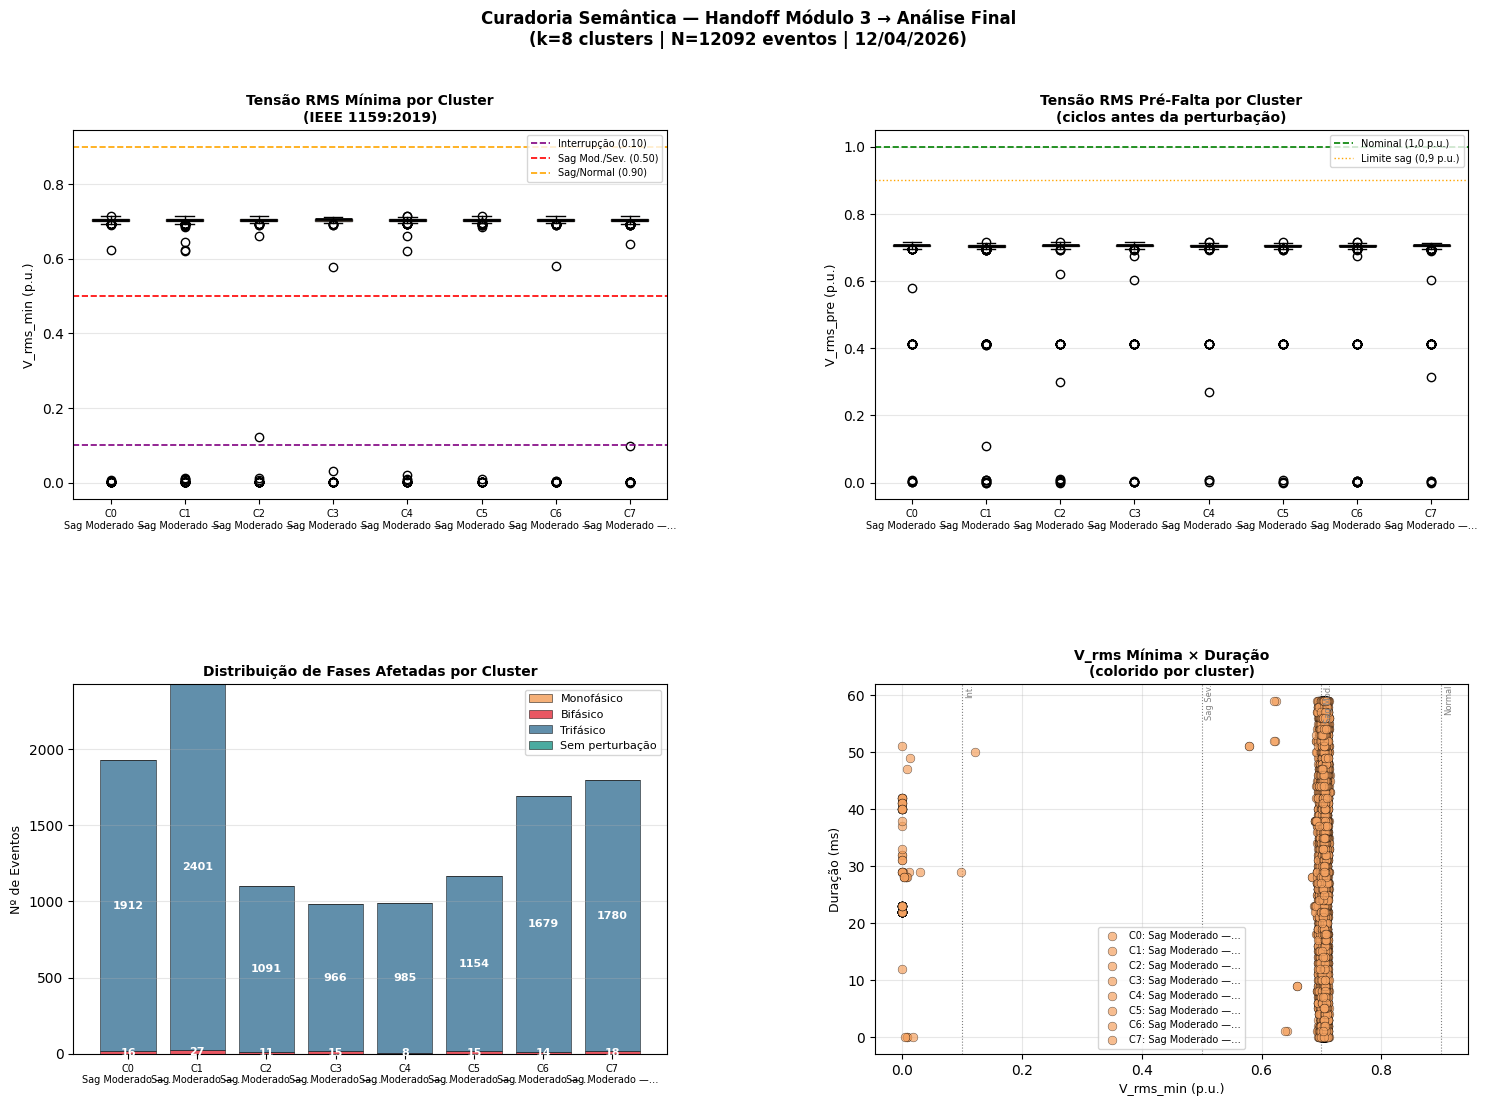

   📈 Painel salvo: 4_dados_curadoria/exec_20260412_1910/painel_curadoria.png


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 9 — Dashboard visual (inalterado — mantém as 4 visualizações)
# ─────────────────────────────────────────────────────────────────────────────

def plotar_painel_curadoria(df_aux, df_curadoria, output_dir):
    K         = len(df_curadoria)
    rotulos   = {r['cluster']: r['rotulo_final'] for _, r in df_curadoria.iterrows()}
    cores_cur = {r['cluster']: r['cor']          for _, r in df_curadoria.iterrows()}
    clusters  = sorted(df_curadoria['cluster'].tolist())

    # Rótulos abreviados para o eixo X (evita sobreposição com k=6)
    def abreviar(s, max_c=14):
        return s if len(s) <= max_c else s[:max_c] + '…'

    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.35)

    # Subplot 1 — Boxplot V_rms_min
    ax1 = fig.add_subplot(gs[0, 0])
    bp1 = ax1.boxplot(
        [df_aux[df_aux['cluster'] == c]['V_rms_min_pu'].values for c in clusters],
        patch_artist=True, medianprops=dict(color='black', linewidth=2)
    )
    for patch, c in zip(bp1['boxes'], clusters):
        patch.set_facecolor(cores_cur[c]); patch.set_alpha(0.75)
    for vl, cor, lab in [
        (0.10, 'purple', 'Interrupção'), (0.50, 'red', 'Sag Mod./Sev.'),
        (0.90, 'orange', 'Sag/Normal')
    ]:
        ax1.axhline(vl, color=cor, lw=1.2, ls='--', label=f'{lab} ({vl:.2f})')
    ax1.set_xticks(range(1, K + 1))
    ax1.set_xticklabels(
        [f"C{c}\n{abreviar(rotulos[c])}" for c in clusters], fontsize=7
    )
    ax1.set_title('Tensão RMS Mínima por Cluster\n(IEEE 1159:2019)',
                  fontsize=10, fontweight='bold')
    ax1.set_ylabel('V_rms_min (p.u.)', fontsize=9)
    ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3, axis='y')

    # Subplot 2 — V_rms_pre por cluster (NOVO: mostra qualidade da pré-falta)
    ax2 = fig.add_subplot(gs[0, 1])
    bp2 = ax2.boxplot(
        [df_aux[df_aux['cluster'] == c]['V_rms_pre_pu'].values for c in clusters],
        patch_artist=True, medianprops=dict(color='black', linewidth=2)
    )
    for patch, c in zip(bp2['boxes'], clusters):
        patch.set_facecolor(cores_cur[c]); patch.set_alpha(0.75)
    ax2.axhline(1.0, color='green', lw=1.2, ls='--', label='Nominal (1,0 p.u.)')
    ax2.axhline(0.90, color='orange', lw=1.0, ls=':', label='Limite sag (0,9 p.u.)')
    ax2.set_xticks(range(1, K + 1))
    ax2.set_xticklabels(
        [f"C{c}\n{abreviar(rotulos[c])}" for c in clusters], fontsize=7
    )
    ax2.set_title('Tensão RMS Pré-Falta por Cluster\n(ciclos antes da perturbação)',
                  fontsize=10, fontweight='bold')
    ax2.set_ylabel('V_rms_pre (p.u.)', fontsize=9)
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3, axis='y')

    # Subplot 3 — Fases afetadas
    ax3 = fig.add_subplot(gs[1, 0])
    fases_labels = ['Monofásico', 'Bifásico', 'Trifásico', 'Sem perturbação']
    fases_cores  = ['#f4a261', '#e63946', '#457b9d', '#2a9d8f']
    fases_counts = {l: [] for l in fases_labels}
    for c in clusters:
        grp = df_aux[df_aux['cluster'] == c]['fases_afetadas']
        fases_counts['Monofásico'].append(int((grp.str.len() == 1).sum()))
        fases_counts['Bifásico'].append(int((grp.str.len() == 2).sum()))
        fases_counts['Trifásico'].append(int((grp == 'ABC').sum()))
        fases_counts['Sem perturbação'].append(
            int((grp == 'Normal').sum() + (grp == '').sum())
        )
    bottom = np.zeros(K)
    for lab, cor in zip(fases_labels, fases_cores):
        vals = np.array(fases_counts[lab])
        ax3.bar(np.arange(K), vals, bottom=bottom, label=lab,
                color=cor, edgecolor='black', lw=0.4, alpha=0.85)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0:
                ax3.text(j, b + v / 2, str(v), ha='center', va='center',
                         fontsize=8, fontweight='bold', color='white')
        bottom += vals
    ax3.set_xticks(np.arange(K))
    ax3.set_xticklabels(
        [f"C{c}\n{abreviar(rotulos[c])}" for c in clusters], fontsize=7
    )
    ax3.set_title('Distribuição de Fases Afetadas por Cluster',
                  fontsize=10, fontweight='bold')
    ax3.set_ylabel('Nº de Eventos', fontsize=9)
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis='y')

    # Subplot 4 — Scatter V_rms_min × Duração
    ax4 = fig.add_subplot(gs[1, 1])
    for c in clusters:
        mask = df_aux['cluster'] == c
        ax4.scatter(
            df_aux.loc[mask, 'V_rms_min_pu'],
            df_aux.loc[mask, 'duracao_ms'],
            color=cores_cur[c], s=40, edgecolors='black',
            linewidths=0.3, label=f"C{c}: {abreviar(rotulos[c])}",
            alpha=0.7, zorder=3
        )
    for vl, lb in [(0.10,'Int.'), (0.50,'Sag Sev.'),
                   (0.70,'Sag Mod.'), (0.90,'Normal')]:
        ax4.axvline(vl, color='gray', lw=0.8, ls=':')
        ax4.text(vl + 0.005, ax4.get_ylim()[1] if ax4.get_ylim()[1] > 0 else 80,
                 lb, fontsize=6, color='gray', rotation=90, va='top')
    ax4.set_title('V_rms Mínima × Duração\n(colorido por cluster)',
                  fontsize=10, fontweight='bold')
    ax4.set_xlabel('V_rms_min (p.u.)', fontsize=9)
    ax4.set_ylabel('Duração (ms)', fontsize=9)
    ax4.legend(fontsize=7); ax4.grid(True, alpha=0.3)

    fig.suptitle(
        f'Curadoria Semântica — Handoff Módulo 3 → Análise Final\n'
        f'(k={K} clusters | N={len(df_aux)} eventos | '
        f'{datetime.now().strftime("%d/%m/%Y")})',
        fontsize=12, fontweight='bold'
    )
    caminho = os.path.join(output_dir, 'painel_curadoria.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Painel salvo: {caminho}")


plotar_painel_curadoria(dados['df_aux'], df_curadoria, OUTPUT_DIR)

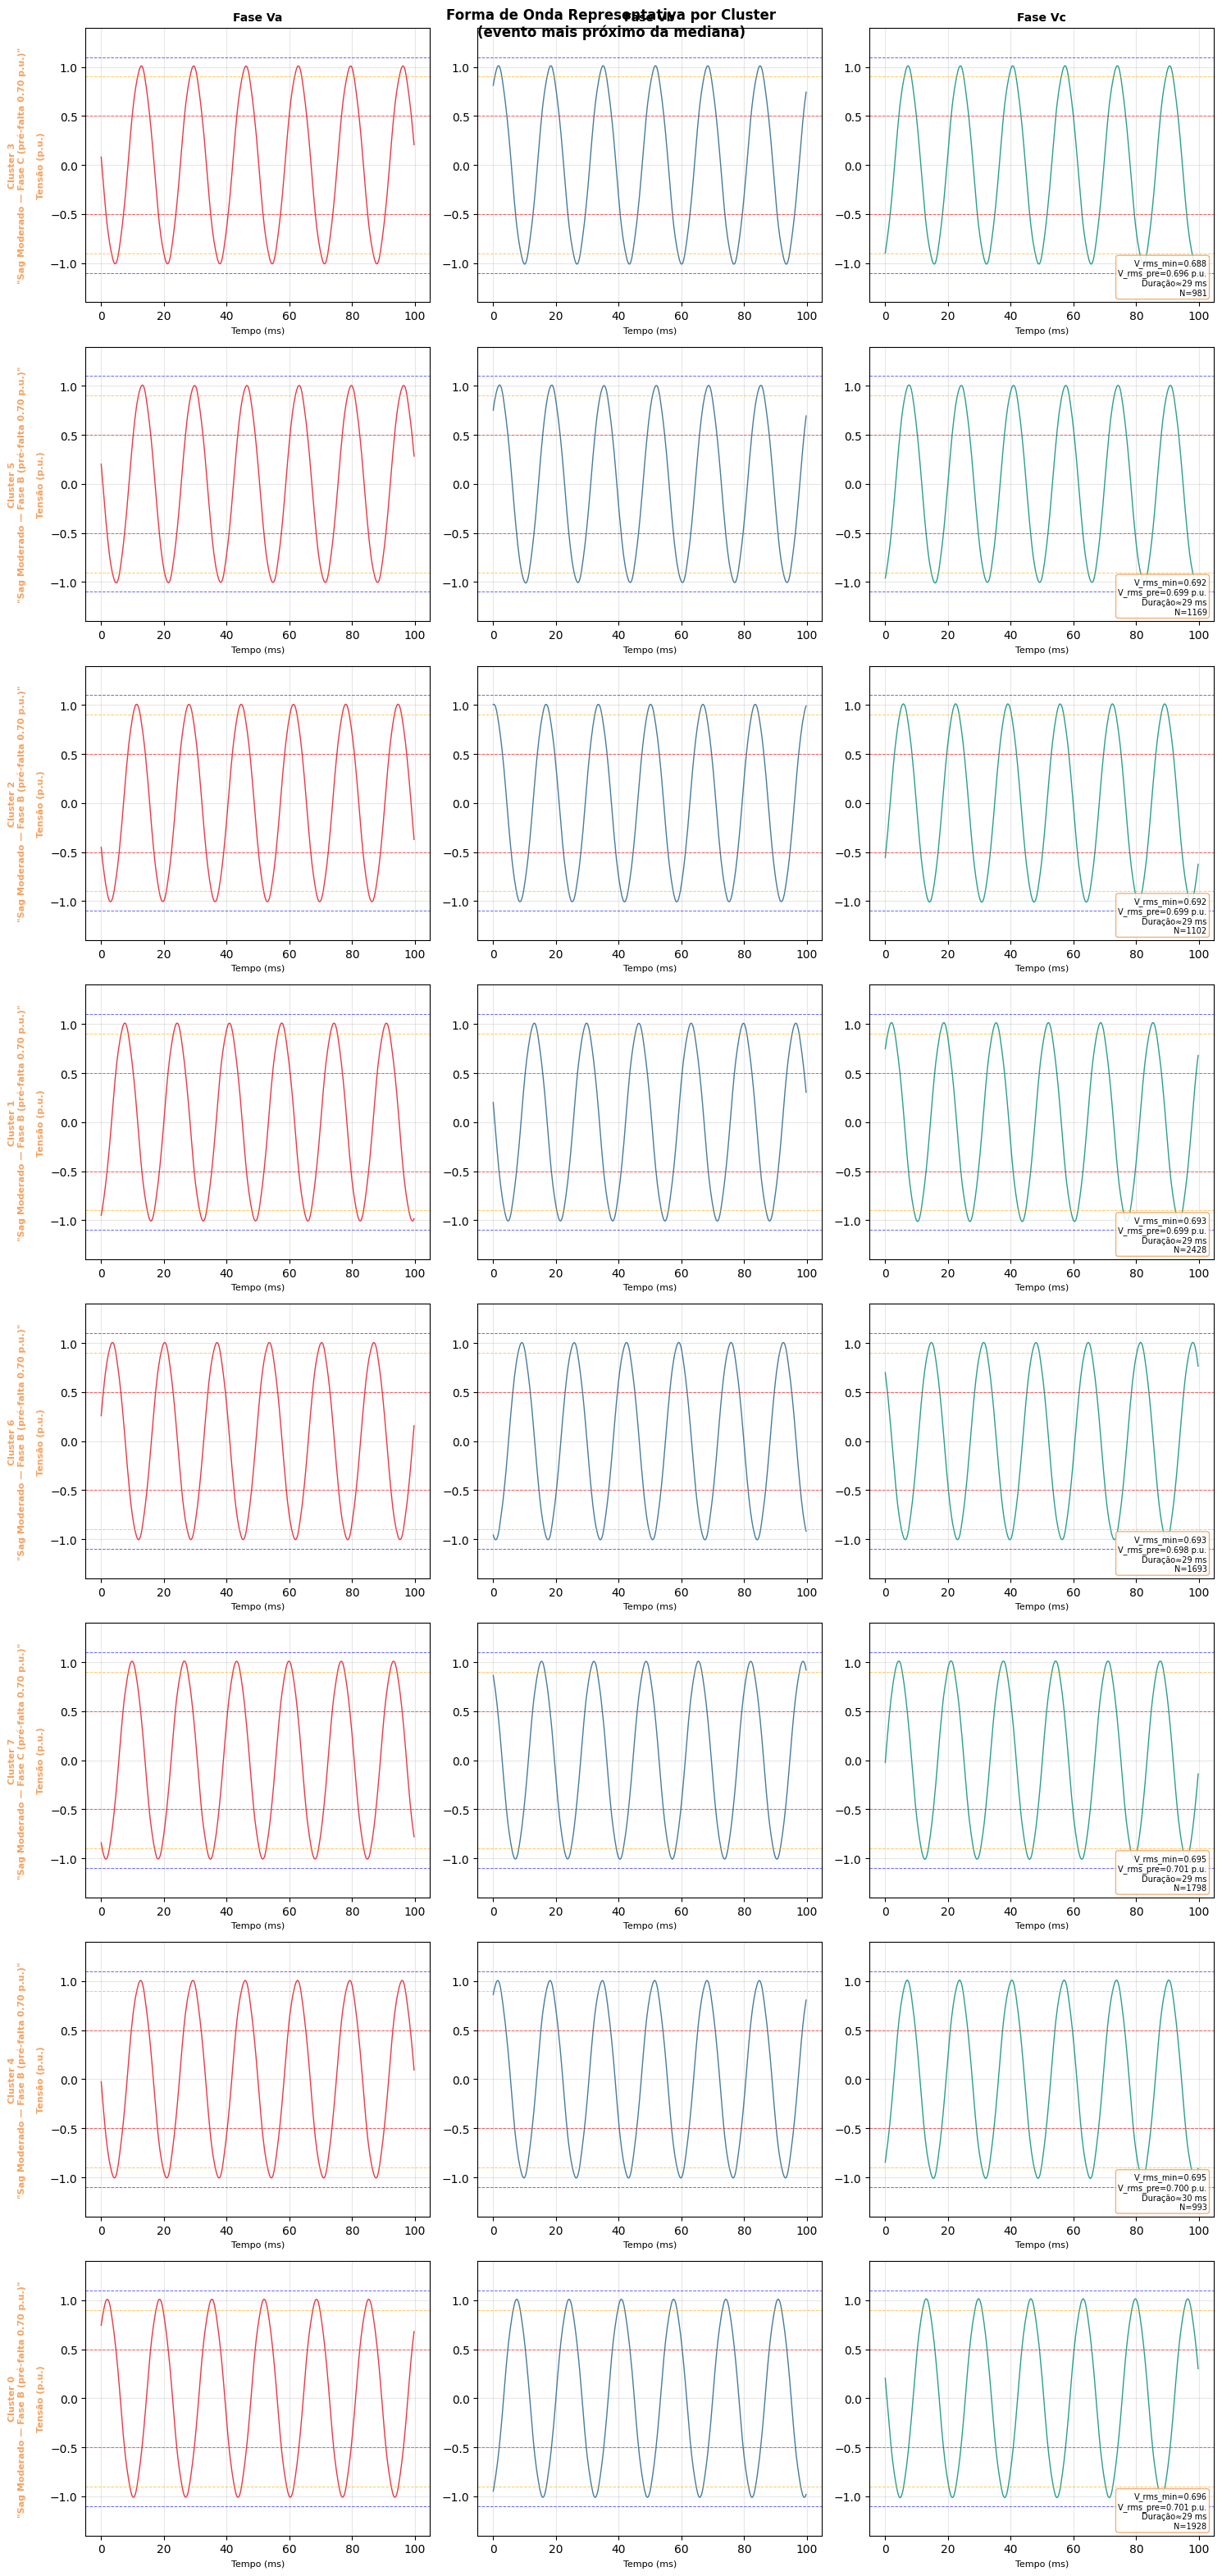

   📈 Formas de onda salvas: 4_dados_curadoria/exec_20260412_1910/formas_onda_representativas.png


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 10 — Formas de onda representativas por cluster
# ─────────────────────────────────────────────────────────────────────────────

def plotar_formas_onda_representativas(df_aux, df_curadoria,
                                       Va_kv, Vb_kv, Vc_kv,
                                       v_nom, spc, freq, output_dir):
    K      = len(df_curadoria)
    dt_ms  = 1 / (spc * freq) * 1e3
    t_ms   = np.arange(WINDOW_SIZE) * dt_ms
    fases  = ['Va', 'Vb', 'Vc']
    canais = [Va_kv, Vb_kv, Vc_kv]
    cores_fase = ['#e63946', '#457b9d', '#2a9d8f']

    fig, axes = plt.subplots(K, 3, figsize=(15, 4 * K))
    if K == 1:
        axes = axes.reshape(1, -1)

    for ri, (_, cur_row) in enumerate(df_curadoria.iterrows()):
        c    = cur_row['cluster']
        cor_c= cur_row['cor']
        grp  = df_aux[df_aux['cluster'] == c]

        mediana      = grp['V_rms_min_pu'].median()
        idx_tipico   = (grp['V_rms_min_pu'] - mediana).abs().idxmin()
        idx_orig     = int(df_aux.loc[idx_tipico, 'evento_idx_orig'])

        for ci, (nf, canal, corf) in enumerate(zip(fases, canais, cores_fase)):
            ax = axes[ri, ci]
            s  = canal[idx_orig] / v_nom
            ax.plot(t_ms, s, color=corf, lw=1.0)
            for vl, cor_ref in [(0.9,'orange'), (0.5,'red'), (-0.9,'orange'),
                                (-0.5,'red'), (1.1,'blue'), (-1.1,'blue')]:
                ax.axhline(vl, color=cor_ref, lw=0.7, ls='--', alpha=0.6)
            ax.set_ylim(-1.4, 1.4)
            ax.set_xlabel('Tempo (ms)', fontsize=8)
            ax.grid(True, alpha=0.3)
            if ci == 0:
                rotulo_str = cur_row['rotulo_final']
                ax.set_ylabel(
                    f"Cluster {c}\n\"{rotulo_str}\"\n\nTensão (p.u.)",
                    fontsize=8, fontweight='bold', color=cor_c
                )
            if ri == 0:
                ax.set_title(f'Fase {nf}', fontsize=10, fontweight='bold')
            if ci == 2:
                ax.text(0.98, 0.02,
                        f"V_rms_min={cur_row['V_rms_min_med']:.3f}\n"
                        f"V_rms_pre={cur_row['V_rms_pre_med']:.3f} p.u.\n"
                        f"Duração≈{cur_row['duracao_ms_med']:.0f} ms\n"
                        f"N={cur_row['n_eventos']}",
                        transform=ax.transAxes, fontsize=7,
                        ha='right', va='bottom',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white',
                                  ec=cor_c, alpha=0.85))

    fig.suptitle('Forma de Onda Representativa por Cluster\n'
                 '(evento mais próximo da mediana)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'formas_onda_representativas.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Formas de onda salvas: {caminho}")


plotar_formas_onda_representativas(
    dados['df_aux'], df_curadoria,
    dados['Va_kv'], dados['Vb_kv'], dados['Vc_kv'],
    V_NOMINAL_PEAK_KV, SAMPLES_PER_CYCLE, FREQ_NOMINAL_HZ, OUTPUT_DIR
)

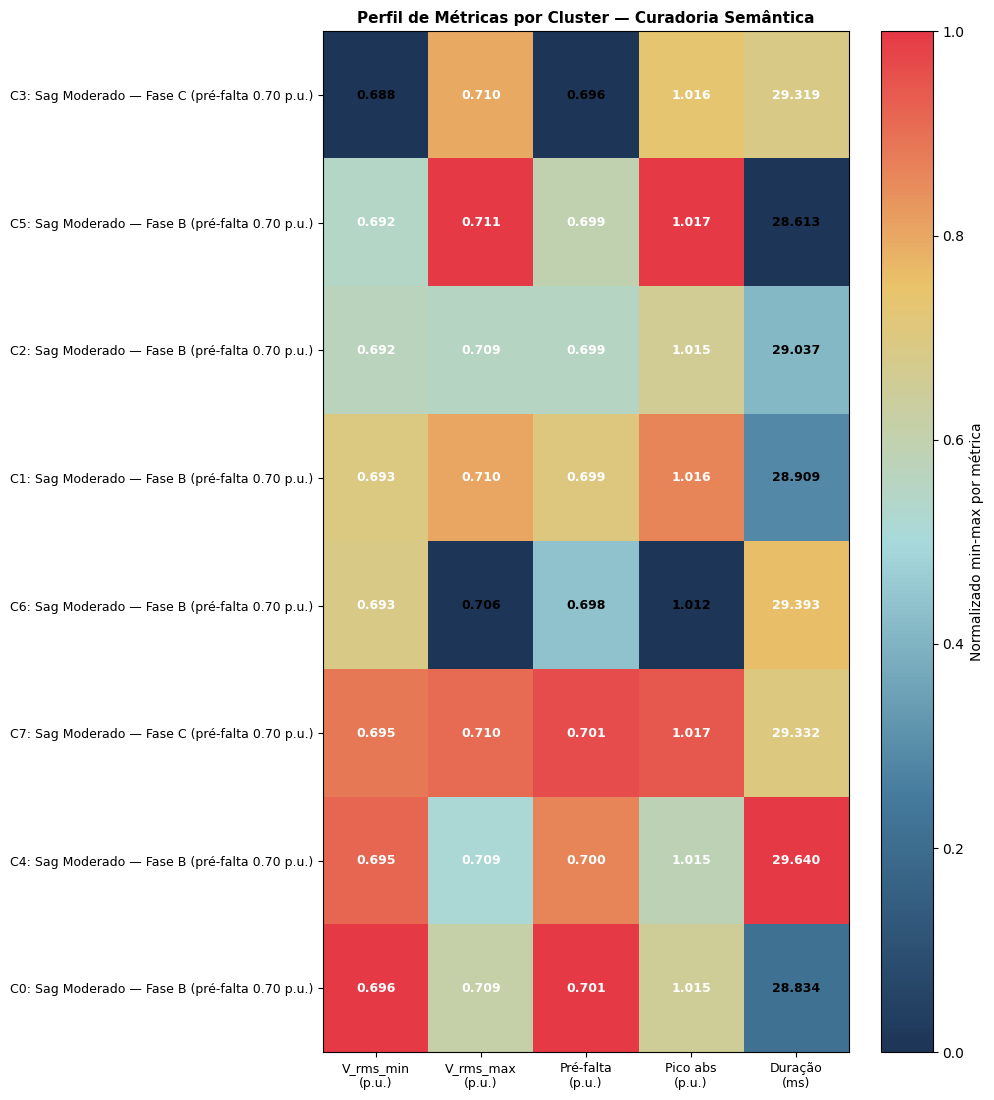

   📈 Heatmap salvo: 4_dados_curadoria/exec_20260412_1910/heatmap_perfil_clusters.png


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 11 — Heatmap de perfil por cluster
# ─────────────────────────────────────────────────────────────────────────────

def plotar_heatmap_perfil(df_aux, df_curadoria, output_dir):
    metricas = {
        'V_rms_min\n(p.u.)':    'V_rms_min_pu',
        'V_rms_max\n(p.u.)':    'V_rms_max_pu',
        'Pré-falta\n(p.u.)':    'V_rms_pre_pu',
        'Pico abs\n(p.u.)':     'amp_pico_pu',
        'Duração\n(ms)':         'duracao_ms',
    }
    K     = len(df_curadoria)
    nomes = [f"C{r['cluster']}: {r['rotulo_final']}"
             for _, r in df_curadoria.iterrows()]

    matriz = np.zeros((K, len(metricas)))
    for i, (_, cur_row) in enumerate(df_curadoria.iterrows()):
        grp = df_aux[df_aux['cluster'] == cur_row['cluster']]
        for j, col in enumerate(metricas.values()):
            matriz[i, j] = grp[col].mean()

    matriz_norm = matriz.copy()
    for j in range(matriz.shape[1]):
        mn, mx = matriz[:, j].min(), matriz[:, j].max()
        if mx > mn:
            matriz_norm[:, j] = (matriz[:, j] - mn) / (mx - mn)

    cmap = LinearSegmentedColormap.from_list(
        'c', ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#e63946']
    )
    fig, ax = plt.subplots(figsize=(10, max(3, K * 1.2 + 1.5)))
    im = ax.imshow(matriz_norm, aspect='auto', cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Normalizado min-max por métrica')
    for i in range(K):
        for j in range(len(metricas)):
            v   = matriz[i, j]
            txt = f"{v:.3f}" if v < 100 else f"{v:.0f}"
            ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                    fontweight='bold',
                    color='white' if matriz_norm[i, j] > 0.5 else 'black')
    ax.set_xticks(range(len(metricas)))
    ax.set_xticklabels(list(metricas.keys()), fontsize=9)
    ax.set_yticks(range(K))
    ax.set_yticklabels(nomes, fontsize=9)
    ax.set_title('Perfil de Métricas por Cluster — Curadoria Semântica',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'heatmap_perfil_clusters.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Heatmap salvo: {caminho}")


plotar_heatmap_perfil(dados['df_aux'], df_curadoria, OUTPUT_DIR)

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 12 — Análise de anomalias com identidade semântica
# ─────────────────────────────────────────────────────────────────────────────

def analisar_anomalias_semanticas(df_aux, df_curadoria, df_anomalias,
                                   mapeamento, N_orig, N_label, output_dir):
    rotulos = {r['cluster']: r['rotulo_final'] for _, r in df_curadoria.iterrows()}
    df_flag = df_anomalias[df_anomalias['flag_anomalia'] == True].copy()

    if mapeamento == 'direto':
        df_flag = df_flag.merge(
            df_aux[['evento_idx_orig', 'V_rms_min_pu', 'duracao_ms',
                    'fases_afetadas', 'cluster']],
            left_on='evento_idx', right_on='evento_idx_orig', how='left'
        )
    else:
        df_flag['evento_idx_orig'] = (
            df_flag['evento_idx'] * N_orig // N_label
        ).clip(0, N_orig - 1).astype(int)
        df_flag = df_flag.merge(
            df_aux[['evento_idx_orig', 'V_rms_min_pu', 'duracao_ms',
                    'fases_afetadas', 'cluster']],
            on='evento_idx_orig', how='left'
        )

    col_cluster = 'cluster_x' if 'cluster_x' in df_flag.columns else 'cluster'
    df_flag['rotulo_semantico'] = df_flag[col_cluster].map(rotulos)

    print(f"\n⚠️  Anomalias detectadas: {len(df_flag)} eventos")
    for c in sorted(rotulos.keys()):
        mask_c = (df_flag[col_cluster] == c)
        n_c    = int(mask_c.sum())
        if n_c > 0:
            dmax = float(df_flag.loc[mask_c, 'dist_centroide'].max())
            print(f"   [{c}] {rotulos[c]}: {n_c}  (dist_max={dmax:.3f})")

    caminho = os.path.join(output_dir, 'anomalias_semanticas.csv')
    df_flag.to_csv(caminho, index=False)
    print(f"   💾 Salvo: {caminho}")
    return df_flag


df_anom_sem = analisar_anomalias_semanticas(
    dados['df_aux'], df_curadoria, dados['df_anomalias'],
    dados['mapeamento'], dados['N_orig'], dados['N_label'], OUTPUT_DIR
)


⚠️  Anomalias detectadas: 1196 eventos
   [0] Sag Moderado — Fase B (pré-falta 0.70 p.u.): 177  (dist_max=2.141)
   [1] Sag Moderado — Fase B (pré-falta 0.70 p.u.): 243  (dist_max=1.886)
   [2] Sag Moderado — Fase B (pré-falta 0.70 p.u.): 111  (dist_max=8.863)
   [3] Sag Moderado — Fase C (pré-falta 0.70 p.u.): 98  (dist_max=49.545)
   [4] Sag Moderado — Fase B (pré-falta 0.70 p.u.): 100  (dist_max=13.973)
   [5] Sag Moderado — Fase B (pré-falta 0.70 p.u.): 117  (dist_max=2.891)
   [6] Sag Moderado — Fase B (pré-falta 0.70 p.u.): 170  (dist_max=2.270)
   [7] Sag Moderado — Fase C (pré-falta 0.70 p.u.): 180  (dist_max=2.237)
   💾 Salvo: 4_dados_curadoria/exec_20260412_1910/anomalias_semanticas.csv


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 13 — Curadoria híbrida + salvamento final
# ─────────────────────────────────────────────────────────────────────────────

def salvar_artefatos_finais(df_curadoria, df_aux, df_anomalias,
                             dados, output_dir):
    mapa_rotulos = df_curadoria.set_index('cluster')['rotulo_final'].to_dict()
    mapa_descr   = df_curadoria.set_index('cluster')['descricao_final'].to_dict()
    df_final     = df_aux.copy()

    # ── Curadoria híbrida (lógica original do aluno, corrigida) ──────────────
    flag_anom = pd.Series(False, index=df_final.index)
    if dados['mapeamento'] == 'direto':
        idx_anomalos = df_anomalias[
            df_anomalias['flag_anomalia'] == True
        ]['evento_idx'].values
    else:
        idx_anomalos = list(set(
            min(int(j * dados['N_orig'] / dados['N_label']), dados['N_orig'] - 1)
            for j in df_anomalias[df_anomalias['flag_anomalia'] == True]['evento_idx']
        ))
    flag_anom.loc[idx_anomalos] = True
    df_final['flag_anomalia_hibrida'] = flag_anom

    rotulo_h, descr_h = [], []
    for _, row in df_final.iterrows():
        if row['flag_anomalia_hibrida']:
            rotulo_h.append('Anomalia (Inspeção Manual)')
            descr_h.append('Evento anômalo intra-cluster. Requer inspeção.')
        elif row['V_rms_min_pu'] < 0.10:
            rotulo_h.append('Interrupção')
            descr_h.append('Interrupção de Tensão (V_rms_min < 0,1 p.u.)')
        elif row['V_rms_max_pu'] > 1.10:
            rotulo_h.append('Swell / Transiente')
            descr_h.append('Elevação ou Transiente (V_rms_max > 1,1 p.u.)')
        else:
            rotulo_h.append(mapa_rotulos.get(row['cluster'], 'Desconhecido'))
            descr_h.append(mapa_descr.get(row['cluster'], 'Cluster K-Means.'))

    df_final['rotulo_semantico_hibrido'] = rotulo_h
    df_final['descricao_ieee_hibrida']   = descr_h

    # Salvar
    df_curadoria.to_csv(os.path.join(output_dir, 'curadoria_clusters.csv'),
                         index=False)
    df_final.to_csv(os.path.join(output_dir, 'eventos_rotulados_hibrido.csv'),
                    index=False)

    # Distribuição do rótulo híbrido
    dist_hibrido = df_final['rotulo_semantico_hibrido'].value_counts()
    print("\n📊 Distribuição final — Curadoria Híbrida:")
    for rotulo, n in dist_hibrido.items():
        print(f"   {rotulo}: {n} ({n/len(df_final)*100:.1f}%)")

    meta = {
        'data_execucao'     : datetime.now().isoformat(),
        'n_eventos'         : int(len(df_aux)),
        'k_clusters'        : int(len(df_curadoria)),
        'k_otimo_silhouette': int(k_otimo),
        'sil_score_atual'   : round(float(sil_atual), 6),
        'delta_vrms_clusters': round(float(delta_vrms), 4),
        'mapeamento'        : dados['mapeamento'],
        'v_nominal_peak_kv' : V_NOMINAL_PEAK_KV,
        'clusters': [
            {
                'cluster'          : int(r['cluster']),
                'rotulo_final'     : r['rotulo_final'],
                'descricao'        : r['descricao_final'],
                'n_eventos'        : int(r['n_eventos']),
                'pct_total'        : float(r['pct_total']),
                'V_rms_min_med'    : float(r['V_rms_min_med']),
                'V_rms_min_std'    : float(r['V_rms_min_std']),
                'V_rms_pre_med'    : float(r['V_rms_pre_med']),
                'fase_dominante'   : r['fase_dominante'],
                'duracao_ms_med'   : float(r['duracao_ms_med']),
            }
            for _, r in df_curadoria.iterrows()
        ]
    }
    with open(os.path.join(output_dir, 'curadoria_metadata.json'), 'w',
              encoding='utf-8') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    print(f"\n💾 Artefatos em '{output_dir}/':")
    print(f"   ├── curadoria_clusters.csv")
    print(f"   ├── eventos_rotulados_hibrido.csv   ({len(df_final)} eventos)")
    print(f"   ├── anomalias_semanticas.csv")
    print(f"   └── curadoria_metadata.json")


salvar_artefatos_finais(
    df_curadoria, dados['df_aux'], dados['df_anomalias'], dados, OUTPUT_DIR
)


📊 Distribuição final — Curadoria Híbrida:
   Sag Moderado — Fase B (pré-falta 0.70 p.u.): 8280 (68.5%)
   Sag Moderado — Fase C (pré-falta 0.70 p.u.): 2463 (20.4%)
   Anomalia (Inspeção Manual): 1196 (9.9%)
   Interrupção: 153 (1.3%)

💾 Artefatos em '4_dados_curadoria/exec_20260412_1910/':
   ├── curadoria_clusters.csv
   ├── eventos_rotulados_hibrido.csv   (12092 eventos)
   ├── anomalias_semanticas.csv
   └── curadoria_metadata.json


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 14 — Relatório técnico (MELHORIA M4: resume arquivos por subestação)
# ─────────────────────────────────────────────────────────────────────────────

def gerar_relatorio_textual(df_curadoria, df_aux, df_anom_sem,
                             dados, k_otimo, sil_atual, delta_vrms,
                             output_dir):
    K         = len(df_curadoria)
    N_orig    = dados['N_orig']
    N_anom    = int(dados['df_anomalias']['flag_anomalia'].sum())
    data_exec = datetime.now().strftime('%d/%m/%Y %H:%M')
    linhas    = []

    def sep(c='═', n=68): linhas.append(c * n)
    def item(t):          linhas.append(f"      • {t}")
    def vazio():          linhas.append("")

    sep()
    linhas.append("  RELATÓRIO TÉCNICO — CURADORIA SEMÂNTICA DE PERTURBAÇÕES ELÉTRICAS")
    linhas.append(f"  Rafael Benzaquem Neto | UFRR — ECAI 4.0 | {data_exec}")
    sep(); vazio()

    # ── 1. Contexto — MELHORIA M4: resumo por subestação ─────────────────────
    linhas.append("1. CONTEXTO E BASE DE DADOS")
    sep('─')

    # Resumo por subestação (padrão de nome: Q<ID>_detection.mat)
    df_aux_copia = df_aux.copy()
    df_aux_copia['subestacao'] = df_aux_copia['arquivo_origem'].str.extract(
        r'(Sub\d+|sub\d+)', expand=False
    ).fillna('Subestação desconhecida')

    sub_resumo = df_aux_copia.groupby('subestacao')['arquivo_origem'].nunique()

    total_arquivos = df_aux['arquivo_origem'].nunique()
    if len(sub_resumo) > 1:
        for sub, n_arq in sub_resumo.items():
            item(f"{sub}: {n_arq} arquivos .mat")
    else:
        item(f"Total de arquivos .mat processados: {total_arquivos}")

    item(f"Total de eventos analisados   : {N_orig}")
    item(f"Dimensão espaço latente (CAE) : {dados['Z'].shape[1]}")
    item(f"Número de clusters (K-Means)  : {K}")
    item(f"k ótimo por Silhouette Score  : {k_otimo}  "
         f"(atual={K}{'✅' if k_otimo==K else ' — considere reotimizar'})")
    item(f"Silhouette Score atual        : {sil_atual:.4f}")
    item(f"ΔV_rms entre clusters         : {delta_vrms:.4f} p.u.  "
         f"({'separação física significativa' if delta_vrms >= 0.05 else 'subclasses dentro da mesma categoria IEEE'})")
    item(f"Total de anomalias detectadas : {N_anom} ({N_anom/N_orig*100:.1f}%)")
    item(f"Referência normativa          : IEEE Std 1159:2019")
    vazio()

    # ── 2. Caracterização por cluster ────────────────────────────────────────
    linhas.append("2. CARACTERIZAÇÃO POR CLUSTER")
    sep('─')
    for _, row in df_curadoria.iterrows():
        c = row['cluster']
        vazio()
        rotulo_str = row['rotulo_final']
        linhas.append(f"  ┌─ CLUSTER {c} — \"{rotulo_str}\" "
                       f"{'─' * max(0, 38 - len(rotulo_str))}")
        linhas.append(f"  │  Descrição  : {row['descricao_final']}")
        linhas.append(f"  │  N eventos  : {row['n_eventos']} ({row['pct_total']}%)")
        linhas.append(f"  │  V_rms_min  : {row['V_rms_min_med']:.4f} ± "
                       f"{row['V_rms_min_std']:.4f} p.u.")
        linhas.append(f"  │  V_rms_pre  : {row['V_rms_pre_med']:.4f} p.u. (pré-falta)")
        linhas.append(f"  │  V_rms_max  : {row['V_rms_max_med']:.4f} p.u.")
        linhas.append(f"  │  Duração    : {row['duracao_ms_med']:.1f} ± "
                       f"{row['duracao_ms_std']:.1f} ms")
        linhas.append(f"  │  Fase dom.  : {row['fase_dominante']}  "
                       f"| Trifásicos: {row['n_trifasico']}  "
                       f"| Monofásicos: {row['n_monofasico']}")
        vrms = row['V_rms_min_med']
        for rot, desc, vmin, vmax, _ in IEEE_1159:
            if vmin <= vrms < vmax:
                linhas.append(f"  │  JUSTIFICATIVA: V_rms_min={vrms:.4f} p.u. ∈ "
                               f"[{vmin:.2f},{vmax:.2f}) p.u. → \"{desc}\"")
                break
        linhas.append(f"  └{'─' * 54}")

    vazio()

    # ── 3. Ranking ─────────────────────────────────────────────────────────────
    linhas.append("3. RANKING POR SEVERIDADE (V_rms_min crescente)")
    sep('─')
    h = (f"  {'Cluster':^9} {'Rótulo':^32} {'V_rms_min':^11} "
         f"{'V_rms_pre':^11} {'N':^8}")
    linhas.append(h)
    linhas.append("  " + "─" * 68)
    for _, row in df_curadoria.sort_values('V_rms_min_med').iterrows():
        rotulo_str = row['rotulo_final']
        linhas.append(
            f"  C{row['cluster']:^8} {rotulo_str[:32]:^32} "
            f"{row['V_rms_min_med']:^11.4f} {row['V_rms_pre_med']:^11.4f} "
            f"{row['n_eventos']:^8}"
        )
    vazio()

    # ── 4. Anomalias ──────────────────────────────────────────────────────────
    linhas.append("4. EVENTOS ANÔMALOS — TRIAGEM PARA INSPEÇÃO MANUAL")
    sep('─')
    linhas.append(f"  Total : {N_anom} eventos ({N_anom/N_orig*100:.1f}%)")
    linhas.append(f"  Critério: distância ao centroide > P90 intra-cluster")
    vazio()
    rotulos_map = {r['cluster']: r['rotulo_final'] for _, r in df_curadoria.iterrows()}
    col_c = 'cluster_x' if 'cluster_x' in df_anom_sem.columns else 'cluster'
    for c in sorted(rotulos_map):
        n_a = int((df_anom_sem[col_c] == c).sum()) if col_c in df_anom_sem.columns else 0
        linhas.append(f"  Cluster {c} ({rotulos_map[c]}): {n_a} anomalias")
    vazio()

    # ── 5. Considerações finais ────────────────────────────────────────────────
    linhas.append("5. CONSIDERAÇÕES FINAIS")
    sep('─')
    linhas.append(textwrap.fill(
        f"  O pipeline não supervisionado segregou automaticamente os {N_orig} "
        f"eventos em {K} grupos. O k ótimo por Silhouette Score é {k_otimo} "
        f"(atual: {K}). A separação física entre clusters é ΔV_rms={delta_vrms:.4f} p.u., "
        f"{'suficiente para categorias IEEE 1159 distintas' if delta_vrms >= 0.05 else 'indicando subclasses dentro da mesma categoria IEEE 1159 — esperado quando a base contém predominantemente um tipo de perturbação'}. "
        f"Os {N_anom} eventos anômalos ({N_anom/N_orig*100:.1f}%) merecem inspeção "
        f"prioritária.",
        width=68, subsequent_indent="  "
    ))
    vazio(); sep(); vazio()

    relatorio = '\n'.join(linhas)
    print(relatorio)
    caminho = os.path.join(output_dir, 'relatorio_curadoria_semantica.txt')
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(relatorio)
    print(f"\n   💾 Relatório salvo: {caminho}")
    return relatorio


relatorio = gerar_relatorio_textual(
    df_curadoria, dados['df_aux'], df_anom_sem,
    dados, k_otimo, sil_atual, delta_vrms, OUTPUT_DIR
)

════════════════════════════════════════════════════════════════════
  RELATÓRIO TÉCNICO — CURADORIA SEMÂNTICA DE PERTURBAÇÕES ELÉTRICAS
  Rafael Benzaquem Neto | UFRR — ECAI 4.0 | 12/04/2026 19:13
════════════════════════════════════════════════════════════════════

1. CONTEXTO E BASE DE DADOS
────────────────────────────────────────────────────────────────────
      • Total de arquivos .mat processados: 327
      • Total de eventos analisados   : 12092
      • Dimensão espaço latente (CAE) : 16
      • Número de clusters (K-Means)  : 8
      • k ótimo por Silhouette Score  : 8  (atual=8✅)
      • Silhouette Score atual        : 0.4981
      • ΔV_rms entre clusters         : 0.0076 p.u.  (subclasses dentro da mesma categoria IEEE)
      • Total de anomalias detectadas : 1196 (9.9%)
      • Referência normativa          : IEEE Std 1159:2019

2. CARACTERIZAÇÃO POR CLUSTER
────────────────────────────────────────────────────────────────────

  ┌─ CLUSTER 3 — "Sag Moderado — Fase C (pré-f

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 15 — Resumo final do pipeline completo
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("✅  MÓDULO FINAL — CURADORIA SEMÂNTICA CONCLUÍDA")
print("=" * 65)
print(f"\n{'CLUSTER':^10} {'RÓTULO SEMÂNTICO':^36} {'V_rms_min':^11} {'N':^6}")
print("─" * 67)
for _, row in df_curadoria.iterrows():
    rotulo_str = row['rotulo_final']
    print(f"  C{row['cluster']:^7} {rotulo_str[:36]:^36} "
          f"{row['V_rms_min_med']:^11.4f} {row['n_eventos']:^6}")

if k_otimo != dados['K']:
    print(f"\n  💡 Considere reotimizar com k={k_otimo} no Módulo 3 "
          f"(Silhouette={sil_atual:.4f})")

print(f"\n📁 Saídas em: '{OUTPUT_DIR}/'")
print("\n" + "─" * 65)
print("🏁 PIPELINE COMPLETO — TCC FINALIZADO")
print("   Módulo 1 : Pré-processamento           → X_cae_input.npy")
print("   Módulo 2 : Autoencoder Convolucional   → Z_latente.npy")
print("   Módulo 3 : Clusterização K-Means       → labels_kmeans.npy")
print("   Módulo F : Curadoria Semântica         → eventos_rotulados_hibrido.csv")
print("=" * 65)



✅  MÓDULO FINAL — CURADORIA SEMÂNTICA CONCLUÍDA

 CLUSTER             RÓTULO SEMÂNTICO            V_rms_min    N   
───────────────────────────────────────────────────────────────────
  C   3    Sag Moderado — Fase C (pré-falta 0.7   0.6880     981  
  C   5    Sag Moderado — Fase B (pré-falta 0.7   0.6922     1169 
  C   2    Sag Moderado — Fase B (pré-falta 0.7   0.6924     1102 
  C   1    Sag Moderado — Fase B (pré-falta 0.7   0.6933     2428 
  C   6    Sag Moderado — Fase B (pré-falta 0.7   0.6933     1693 
  C   7    Sag Moderado — Fase C (pré-falta 0.7   0.6948     1798 
  C   4    Sag Moderado — Fase B (pré-falta 0.7   0.6950     993  
  C   0    Sag Moderado — Fase B (pré-falta 0.7   0.6957     1928 

📁 Saídas em: '4_dados_curadoria/exec_20260412_1910/'

─────────────────────────────────────────────────────────────────
🏁 PIPELINE COMPLETO — TCC FINALIZADO
   Módulo 1 : Pré-processamento           → X_cae_input.npy
   Módulo 2 : Autoencoder Convolucional   → Z_latente.npy
   